In [1]:
import torch as T

## Load the network
net_path = "/home/matthew/Documents/saved_networks/UNetUpscaler/best"
network = T.load(net_path)
network.eval()

/home/matthew/miniconda3/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UNetSuperResolution(
  (unet): UNet(
    (down_sample): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (up_sample): Upsample(scale_factor=2.0, mode=nearest)
    (first_block): ResNetBlock(
      (first_layers): Sequential(
        (0): GroupNorm(1, 3, eps=1e-05, affine=True)
        (1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (2): LeakyReLU(negative_slope=0.1)
        (3): GroupNorm(1, 16, eps=1e-05, affine=True)
      )
      (second_layers): Sequential(
        (0): LeakyReLU(negative_slope=0.1)
        (1): Dropout(p=0.1, inplace=False)
        (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (skip_connection): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
    )
    (encoder_blocks): ModuleList(
      (0): ModuleList(
        (0): ResNetBlock(
          (first_layers): Sequential(
            (0): GroupNorm(1, 16, eps=1e-05, affine=True)
            (1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padd

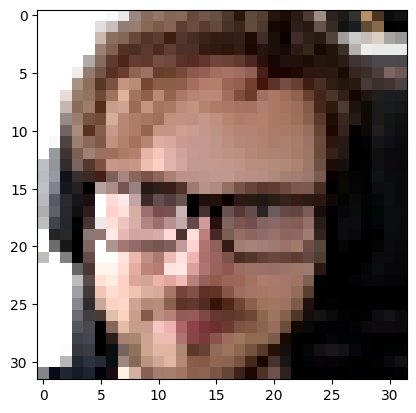

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Load an image
img_path = "test_images/johnny.png"
img = mpimg.imread(img_path)
imgplot = plt.imshow(img)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


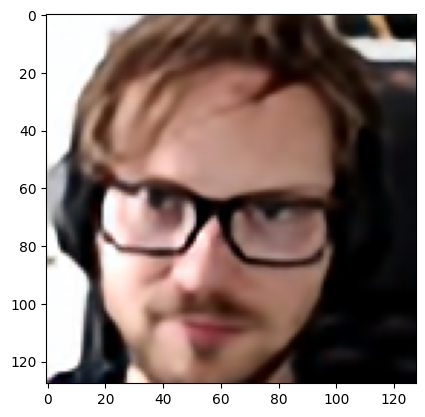

In [3]:
## Pass through the network and plot
import numpy as np
from torchvision.transforms import ToTensor, Normalize

img_tens = ToTensor()(img.copy())
img_tens = Normalize(0.5, 0.5)(img_tens.unsqueeze(0)) # Batch dimension
output = network(img_tens.to(network.device))
output = Normalize(-1, 2)(output.squeeze())
np_out = output.detach().cpu().numpy()
np_out = np.transpose(np_out, (1, 2, 0))
plt.imshow(np_out)